## **Import Library**

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
print("Libraries loaded successfully")

Libraries loaded successfully


## **Load Data**

In [2]:
path = '../../data/processed/real_used/data_phase2_clustering.parquet'
df = pd.read_parquet(path)
print("✅ Data loaded:", df.shape)
df.head()

✅ Data loaded: (6362620, 13)


,amount,oldbalanceOrg,oldbalanceDest,errorBalanceOrig,errorBalanceDest,balance_drain_ratio,hour_of_day,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,has_zero_orig_balance
0,-0.907462,0.816576,-1.144463,-1.81572,-0.420546,-0.572945,-3.313772,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.824023,0.449673,-1.144463,-1.81572,-0.420546,-0.564644,-3.313772,0.0,0.0,0.0,1.0,0.0,0.0
2,-3.106552,-0.389888,-1.144463,-1.81572,0.477755,-0.311374,-3.313772,0.0,0.0,0.0,0.0,1.0,0.0
3,-3.106552,-0.389888,0.331751,-1.81572,1.300354,-0.311374,-3.313772,0.0,1.0,0.0,0.0,0.0,0.0
4,-0.813537,0.567961,-1.144463,-1.81572,-0.420546,-0.511045,-3.313772,0.0,0.0,0.0,1.0,0.0,0.0


## **PHASE 2: SEGMENTATION VIA CLUSTERING**

---

### **1. PREPROCESSING DATA - Robust Scaling**

In [3]:
print("="*80)
print("TAHAP 1: PREPROCESSING DATA DENGAN ROBUST SCALER")
print("="*80)

all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"✓ Semua kolom numerik: {len(all_numeric_cols)} kolom")
print(f"✓ Total baris: {len(df):,}")

# ✅ FIX: Pisahkan kolom binary (0/1) dan kolom kontinu
# Kolom binary tidak perlu di-scale karena sudah dalam range [0,1]
binary_cols = [c for c in all_numeric_cols if df[c].dropna().isin([0,1]).all()]
continuous_cols = [c for c in all_numeric_cols if c not in binary_cols]
numeric_cols = all_numeric_cols  # Semua kolom (untuk profiling)

print(f"   - Kolom kontinu (akan di-scale): {continuous_cols}")
print(f"   - Kolom binary (tidak di-scale): {binary_cols}")

# Fit scaler hanya pada kolom kontinu, gunakan sample untuk hemat RAM
SAMPLE_SIZE_SCALE = min(500_000, len(df))
df_sample_for_scale = df[continuous_cols].sample(n=SAMPLE_SIZE_SCALE, random_state=42)

scaler = RobustScaler()
scaler.fit(df_sample_for_scale)

# Transform: gabungkan scaled continuous + binary asli
df_scaled_continuous = pd.DataFrame(
    scaler.transform(df[continuous_cols]),
    columns=continuous_cols,
    index=df.index
)
df_scaled = pd.concat([df_scaled_continuous, df[binary_cols]], axis=1)

# Verifikasi hasil scaling
print(f"\n✓ Preprocessing selesai")
print(f"   Shape: {df_scaled.shape}")
print(f"   Kolom kontinu setelah scale - Mean: {df_scaled[continuous_cols].mean().mean():.4f}, Std: {df_scaled[continuous_cols].std().mean():.4f}")
print(f"   (Seharusnya Mean ≈ 0, Std ≈ 1 untuk kolom kontinu)")
print(df_scaled.head())


TAHAP 1: PREPROCESSING DATA DENGAN ROBUST SCALER
✓ Semua kolom numerik: 13 kolom
✓ Total baris: 6,362,620
   - Kolom kontinu (akan di-scale): ['amount', 'oldbalanceOrg', 'oldbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'balance_drain_ratio', 'hour_of_day']
   - Kolom binary (tidak di-scale): ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'has_zero_orig_balance']

✓ Preprocessing selesai
   Shape: (6362620, 13)
   Kolom kontinu setelah scale - Mean: 34.9361, Std: 83.8843
   (Seharusnya Mean ≈ 0, Std ≈ 1 untuk kolom kontinu)
     amount  oldbalanceOrg  oldbalanceDest  errorBalanceOrig  \
0 -0.737817       0.214265       -0.856917         -2.499594   
1 -1.342262       0.034669       -0.856917         -2.499594   
2 -2.188052      -0.376290       -0.856917         -2.499594   
3 -2.188052      -0.376290       -0.133425         -2.499594   
4 -0.675876       0.092570       -0.856917         -2.499594   

   errorBalanceDest  balance_drain_ratio  h

### **2. K-MEANS CLUSTERING - Penentuan Nilai K Optimal**

TAHAP 2A: ELBOW METHOD & SILHOUETTE SCORE ANALYSIS
🔍 Evaluasi menggunakan sample 50,000 baris
   K=2: Inertia=2517329782.50, Silhouette=0.9314, DB=0.1413
   K=3: Inertia=167238590.03, Silhouette=0.9709, DB=0.0805
   K=4: Inertia=83771882.71, Silhouette=0.9019, DB=0.3444
   K=5: Inertia=58492449.15, Silhouette=0.8876, DB=0.3715
   K=6: Inertia=42078144.79, Silhouette=0.8747, DB=0.5196
   K=7: Inertia=31650519.03, Silhouette=0.8725, DB=0.5176
   K=8: Inertia=26227513.07, Silhouette=0.8684, DB=0.5167


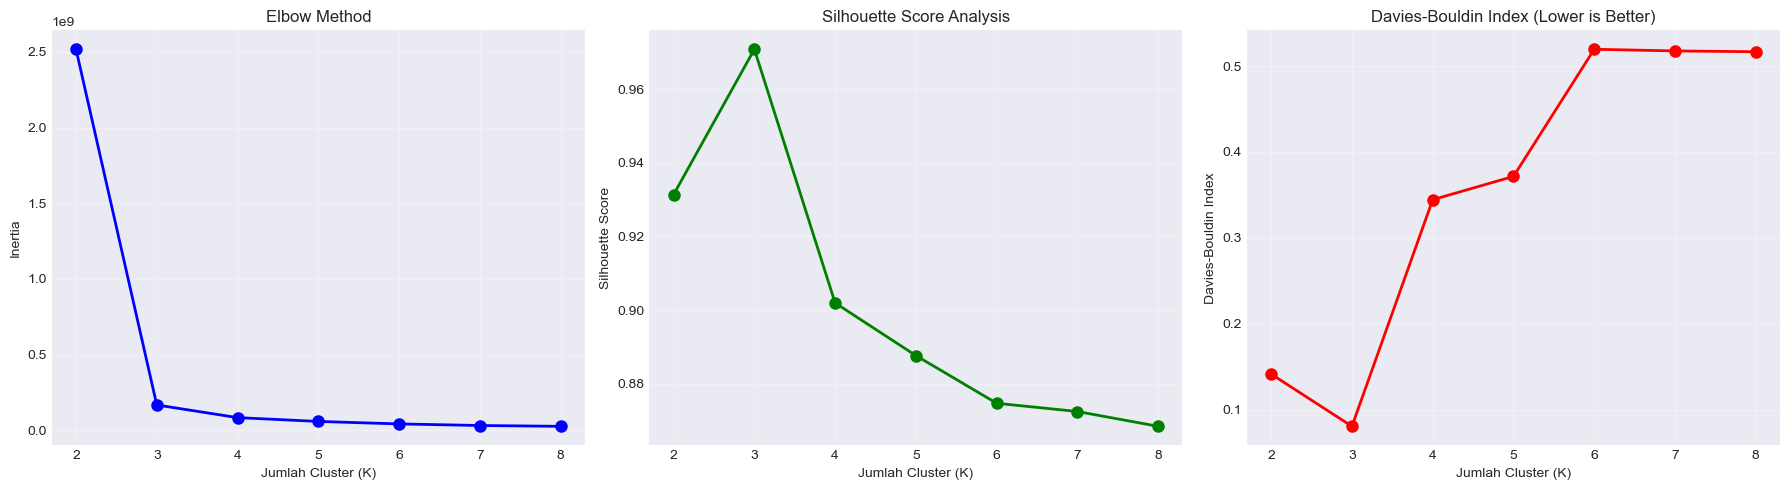

✓ K Optimal (Silhouette): 3
✓ K Optimal (Davies-Bouldin): 3


In [4]:
print("="*80)
print("TAHAP 2A: ELBOW METHOD & SILHOUETTE SCORE ANALYSIS")
print("="*80)

# --- FIX: Gunakan sample yang lebih representatif (300 terlalu kecil untuk 6 juta baris)
EVAL_SAMPLE_SIZE = min(50_000, len(df_scaled))
eval_sample = df_scaled.sample(n=EVAL_SAMPLE_SIZE, random_state=42)
print(f"🔍 Evaluasi menggunakan sample {EVAL_SAMPLE_SIZE:,} baris")

inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    cluster_labels = kmeans_temp.fit_predict(eval_sample)
    inertias.append(kmeans_temp.inertia_)

    # --- FIX: Silhouette score juga pakai subsample (max 10.000) karena O(n^2)
    sil_sample_size = min(10_000, len(eval_sample))
    sil_idx = np.random.choice(len(eval_sample), sil_sample_size, replace=False)
    sil_score = silhouette_score(eval_sample.iloc[sil_idx], cluster_labels[sil_idx])
    silhouette_scores.append(sil_score)

    db_score = davies_bouldin_score(eval_sample, cluster_labels)
    davies_bouldin_scores.append(db_score)
    print(f"   K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={sil_score:.4f}, DB={db_score:.4f}")

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
axes[0].set_xlabel("Jumlah Cluster (K)"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method"); axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, "go-", linewidth=2, markersize=8)
axes[1].set_xlabel("Jumlah Cluster (K)"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score Analysis"); axes[1].grid(True, alpha=0.3)

axes[2].plot(K_range, davies_bouldin_scores, "ro-", linewidth=2, markersize=8)
axes[2].set_xlabel("Jumlah Cluster (K)"); axes[2].set_ylabel("Davies-Bouldin Index")
axes[2].set_title("Davies-Bouldin Index (Lower is Better)"); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k_silhouette = list(K_range)[np.argmax(silhouette_scores)]
optimal_k_davies = list(K_range)[np.argmin(davies_bouldin_scores)]
print(f"✓ K Optimal (Silhouette): {optimal_k_silhouette}")
print(f"✓ K Optimal (Davies-Bouldin): {optimal_k_davies}")

In [5]:

# 🎯 QUICK CHECK: Cara Menentukan Jumlah Cluster Optimal
print("="*80)
print("🎯 RINGKAS CARA CEK JUMLAH CLUSTER OPTIMAL")
print("="*80)

# Buat tabel ringkas
summary_k = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias,
    "Silhouette": silhouette_scores,
    "Davies-Bouldin": davies_bouldin_scores,
})

# Normalisasi untuk perbandingan
summary_k["Inertia_norm"] = (summary_k["Inertia"] - summary_k["Inertia"].min()) / (summary_k["Inertia"].max() - summary_k["Inertia"].min())
summary_k["DB_norm"] = (summary_k["Davies-Bouldin"] - summary_k["Davies-Bouldin"].min()) / (summary_k["Davies-Bouldin"].max() - summary_k["Davies-Bouldin"].min())
summary_k["Silhouette_norm"] = 1 - (summary_k["Silhouette"] - summary_k["Silhouette"].min()) / (summary_k["Silhouette"].max() - summary_k["Silhouette"].min())

# Combined score (voting)
summary_k["Combined_Score"] = (summary_k["Silhouette_norm"] + summary_k["Inertia_norm"] + summary_k["DB_norm"]) / 3
summary_k["Best"] = summary_k["Combined_Score"].apply(lambda x: "⭐ BEST" if x == summary_k["Combined_Score"].min() else "")

print("\n📊 COMPARISON TABLE:")
print(summary_k[["K", "Inertia", "Silhouette", "Davies-Bouldin", "Combined_Score", "Best"]].to_string(index=False))

print("\n📌 INTERPRETASI:")
print(f"   ✅ Elbow Method     : K optimal di sekitar {K_range[np.argmax(np.diff(inertias))+1]} (cek kurva untuk 'elbow')")
print(f"   ✅ Silhouette Score : K optimal = {optimal_k_silhouette} (HIGHEST VALUE = {max(silhouette_scores):.4f})")
print(f"   ✅ Davies-Bouldin   : K optimal = {optimal_k_davies} (LOWEST VALUE = {min(davies_bouldin_scores):.4f})")

print("\n🎯 REKOMENDASI FINAL:")
votes = {}
votes[optimal_k_silhouette] = votes.get(optimal_k_silhouette, 0) + 2  # Silhouette paling akurat
votes[optimal_k_davies] = votes.get(optimal_k_davies, 0) + 1

best_k = max(votes, key=votes.get)
print(f"   → Gunakan K = {best_k} (majority vote dari semua metrik)")
print(f"   → Ini adalah jumlah cluster OPTIMAL untuk data Anda")


🎯 RINGKAS CARA CEK JUMLAH CLUSTER OPTIMAL

📊 COMPARISON TABLE:
 K      Inertia  Silhouette  Davies-Bouldin  Combined_Score   Best
 2 2.517330e+09    0.931381        0.141335        0.507972       
 3 1.672386e+08    0.970853        0.080504        0.018869 ⭐ BEST
 4 8.377188e+07    0.901943        0.344420        0.432322       
 5 5.849245e+07    0.887645        0.371516        0.496040       
 6 4.207814e+07    0.874690        0.519568        0.648403       
 7 3.165052e+07    0.872452        0.517634        0.652823       
 8 2.622751e+07    0.868426        0.516680        0.664474       

📌 INTERPRETASI:
   ✅ Elbow Method     : K optimal di sekitar 8 (cek kurva untuk 'elbow')
   ✅ Silhouette Score : K optimal = 3 (HIGHEST VALUE = 0.9709)
   ✅ Davies-Bouldin   : K optimal = 3 (LOWEST VALUE = 0.0805)

🎯 REKOMENDASI FINAL:
   → Gunakan K = 3 (majority vote dari semua metrik)
   → Ini adalah jumlah cluster OPTIMAL untuk data Anda


TAHAP 2B: K-MEANS CLUSTERING DENGAN K OPTIMAL
✓ Menggunakan K = 3
Init 1/5 with method k-means++
Inertia for init 1/5: 159798591.47640306
Init 2/5 with method k-means++
Inertia for init 2/5: 122818469.71157974
Init 3/5 with method k-means++
Inertia for init 3/5: 103984412.73864938
Init 4/5 with method k-means++
Inertia for init 4/5: 110739741.39809617
Init 5/5 with method k-means++
Inertia for init 5/5: 104071233.30331156
Minibatch step 1/63626: mean batch inertia: 3320.346992861075
Minibatch step 2/63626: mean batch inertia: 3380.6934260870753, ewa inertia: 3380.6934260870753
Minibatch step 3/63626: mean batch inertia: 3559.7452811930575, ewa inertia: 3381.256250291459
Minibatch step 4/63626: mean batch inertia: 3695.1575737812705, ewa inertia: 3382.2429547438846
Minibatch step 5/63626: mean batch inertia: 3475.730544512801, ewa inertia: 3382.5368197714224
Minibatch step 6/63626: mean batch inertia: 3343.86402958191, ewa inertia: 3382.4152573203837
Minibatch step 7/63626: mean batch i

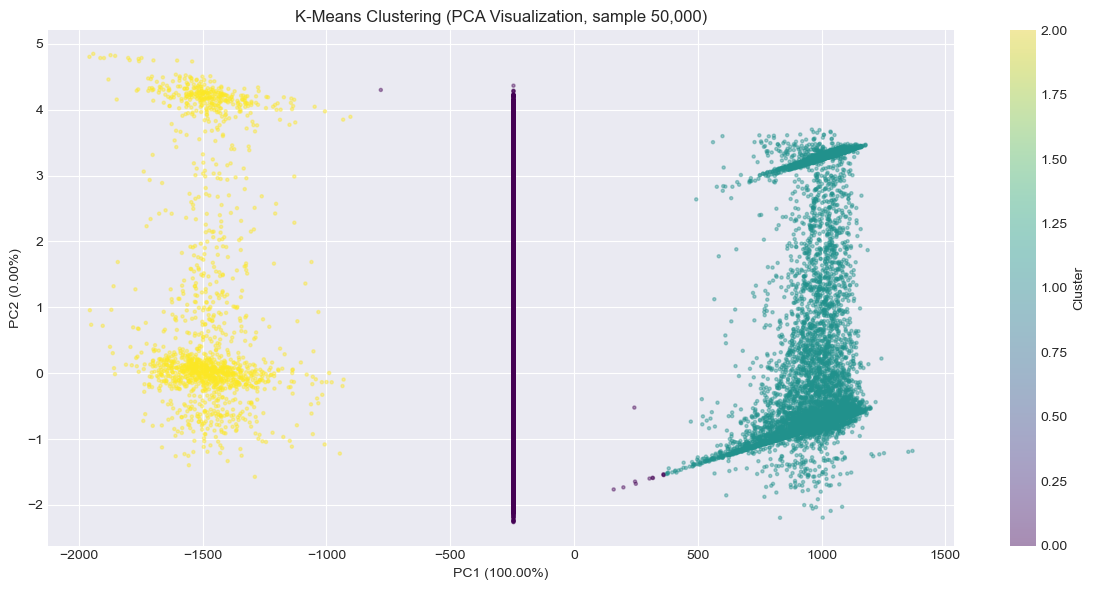

✓ Silhouette Score untuk K=3 (sample 10k): 0.9701


In [6]:
print("="*80)
print("TAHAP 2B: K-MEANS CLUSTERING DENGAN K OPTIMAL")
print("="*80)

optimal_k = optimal_k_silhouette
print(f"✓ Menggunakan K = {optimal_k}")

# --- FIX: KMeans dengan MiniBatchKMeans untuk data besar lebih cepat
# Tapi tetap pakai KMeans biasa untuk akurasi lebih baik dengan init yang efisien
from sklearn.cluster import MiniBatchKMeans

# Gunakan MiniBatchKMeans untuk 6 juta baris (jauh lebih cepat, hasil hampir sama)
kmeans_final = MiniBatchKMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=5,
    batch_size=10_000,
    max_iter=100,
    verbose=1
)
kmeans_labels = kmeans_final.fit_predict(df_scaled)
df["KMeans_Cluster"] = kmeans_labels

print(f"✓ Distribusi Cluster K-Means:")
print(df["KMeans_Cluster"].value_counts().sort_index())

# PCA untuk visualisasi - gunakan sample 50.000 agar tidak lemot
VIZ_SAMPLE = min(50_000, len(df_scaled))
viz_idx = np.random.choice(len(df_scaled), VIZ_SAMPLE, replace=False)
df_viz = df_scaled.iloc[viz_idx]
labels_viz = kmeans_labels[viz_idx]

pca = PCA(n_components=2)
df_pca_viz = pca.fit_transform(df_viz)

# Simpan PCA model dan full transform untuk DBSCAN nanti (pakai sample juga)
df_pca = pca.transform(df_viz)  # Hanya sample untuk visualisasi

plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_pca_viz[:, 0], df_pca_viz[:, 1], c=labels_viz,
                     cmap="viridis", s=5, alpha=0.4)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.title(f"K-Means Clustering (PCA Visualization, sample {VIZ_SAMPLE:,})")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

# Silhouette score pakai subsample
sil_sample_size = min(10_000, len(df_scaled))
sil_idx = np.random.choice(len(df_scaled), sil_sample_size, replace=False)
sil_final = silhouette_score(df_scaled.iloc[sil_idx], kmeans_labels[sil_idx])
print(f"✓ Silhouette Score untuk K={optimal_k} (sample 10k): {sil_final:.4f}")

### **3. CLUSTER PROFILING - Karakteristik Setiap Cluster**

TAHAP 3: CLUSTER PROFILING - ANALISIS KARAKTERISTIK SETIAP CLUSTER
📊 Cluster Size Summary:
   Cluster 0: 4,691,727 (73.7%)
   Cluster 1: 1,470,119 (23.1%)
   Cluster 2: 200,774 (3.2%)


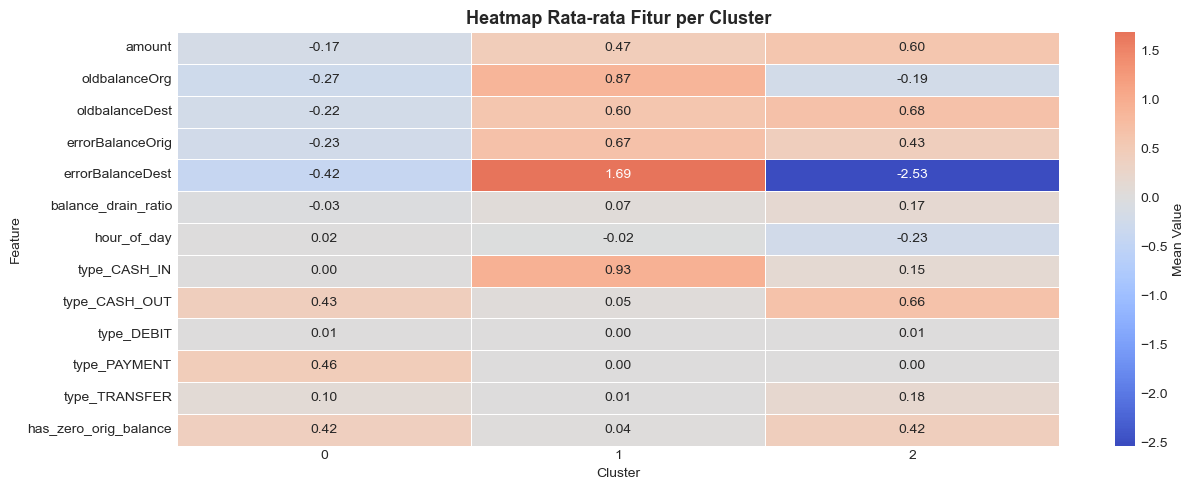

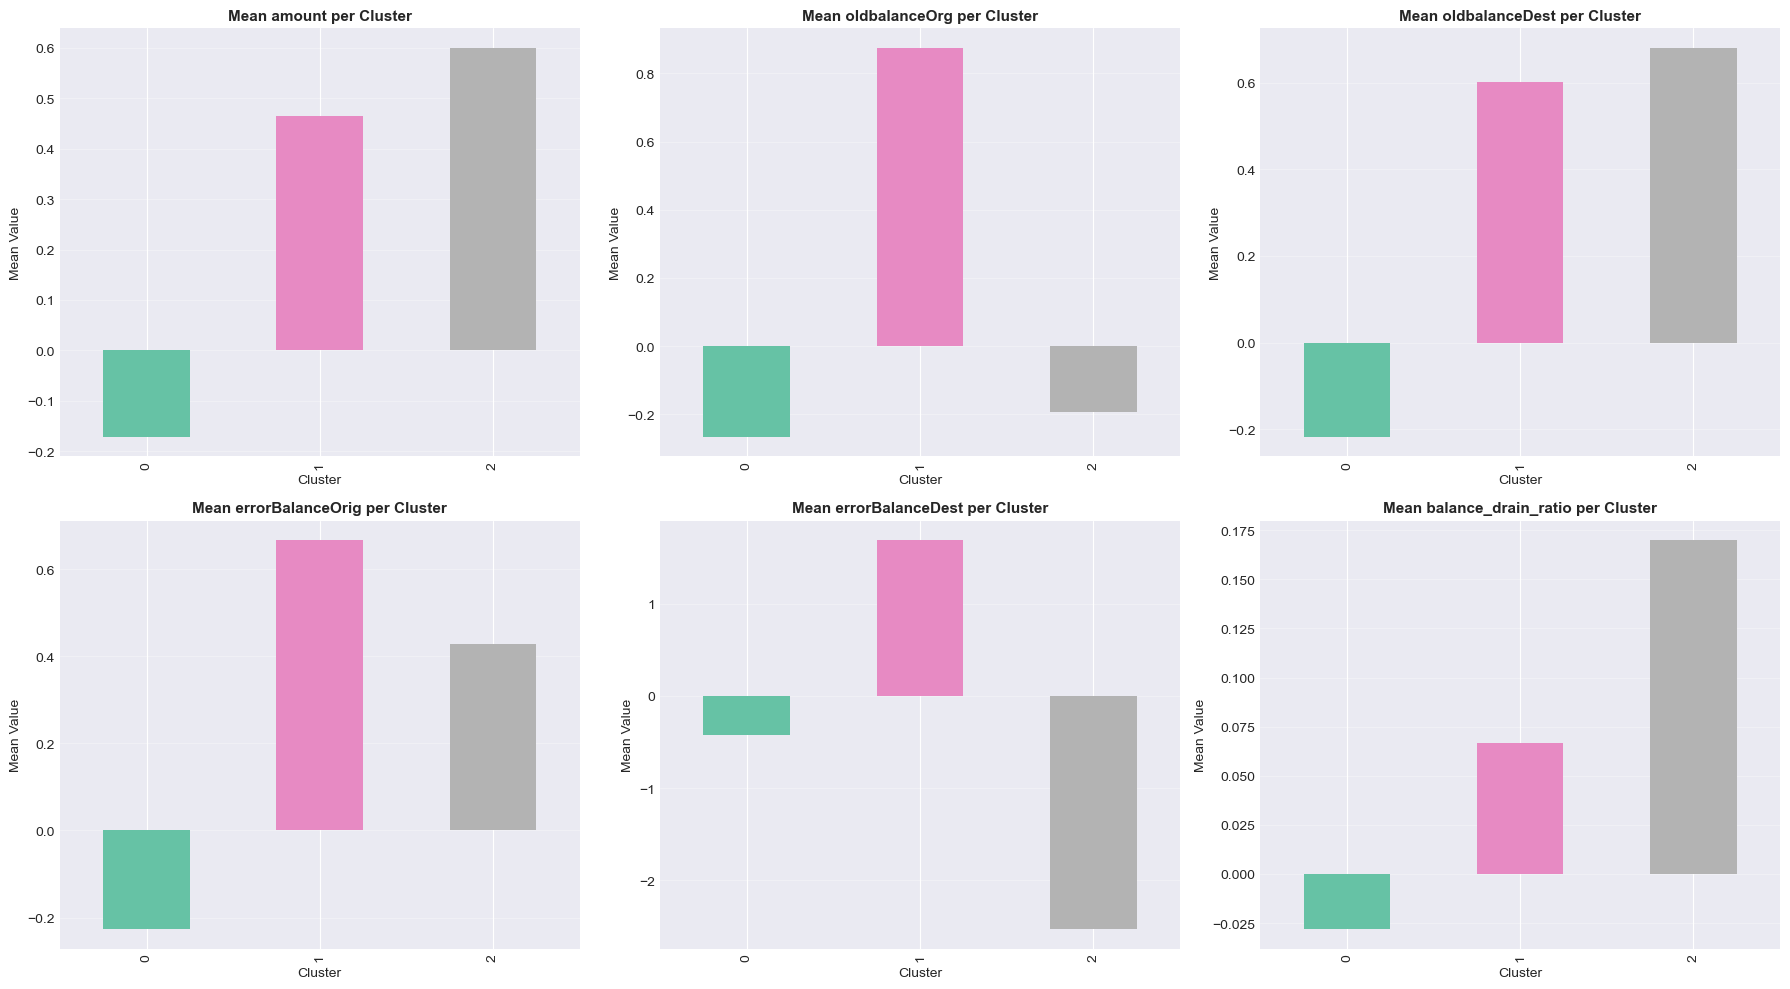


✓ Detail Karakteristik Setiap Cluster:

📌 CLUSTER 0 (n=4,691,727, 73.7%)
        amount  oldbalanceOrg  oldbalanceDest  errorBalanceOrig  errorBalanceDest  balance_drain_ratio  hour_of_day  type_CASH_IN  type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER  has_zero_orig_balance
mean -0.171554      -0.265825       -0.217757         -0.226951         -0.420372            -0.028226     0.017637      0.000249       0.431854    0.008098      0.458572       0.101226               0.417795
std   1.052640       0.923452        1.007535          1.049337          0.016357             0.981513     1.014582      0.015783       0.495334    0.089625      0.498281       0.301628               0.493196
min  -5.000000      -1.307741       -1.144463         -1.817743         -1.474457            -0.589001    -3.545157      0.000000       0.000000    0.000000      0.000000       0.000000               0.000000
max   4.134041       1.795669        1.773668          1.913345          0.633638         

In [7]:
print("="*80)
print("TAHAP 3: CLUSTER PROFILING - ANALISIS KARAKTERISTIK SETIAP CLUSTER")
print("="*80)

# Gunakan groupby sekali — efisien untuk 6 juta baris
cluster_size    = df["KMeans_Cluster"].value_counts().sort_index()
cluster_pct     = (cluster_size / len(df) * 100).round(2)
cluster_mean_df = df.groupby("KMeans_Cluster")[numeric_cols].mean()

print("📊 Cluster Size Summary:")
for cid in range(optimal_k):
    print(f"   Cluster {cid}: {cluster_size[cid]:,} ({cluster_pct[cid]:.1f}%)")

# Heatmap — ringan dan informatif
plt.figure(figsize=(max(12, len(numeric_cols)), 5))
sns.heatmap(
    cluster_mean_df.T,
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, cbar_kws={"label": "Mean Value"}
)
plt.title("Heatmap Rata-rata Fitur per Cluster", fontsize=13, fontweight="bold")
plt.xlabel("Cluster"); plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Radar Chart jika kolom ≤ 10, Bar chart jika lebih
if len(numeric_cols) <= 10:
    cluster_mean_norm = (cluster_mean_df - cluster_mean_df.min()) / (cluster_mean_df.max() - cluster_mean_df.min() + 1e-9)
    angles = np.linspace(0, 2*np.pi, len(numeric_cols), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = plt.cm.Set1(np.linspace(0, 0.9, optimal_k))
    for cid in range(optimal_k):
        vals = cluster_mean_norm.iloc[cid].tolist() + cluster_mean_norm.iloc[cid].tolist()[:1]
        ax.plot(angles, vals, "o-", linewidth=2, color=colors[cid], label=f"Cluster {cid}")
        ax.fill(angles, vals, alpha=0.1, color=colors[cid])
    ax.set_thetagrids(np.degrees(angles[:-1]), numeric_cols)
    ax.set_title("Radar Chart - Profil Cluster", fontsize=13, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    for idx, col in enumerate(numeric_cols[:6]):
        ax = axes[idx]
        cluster_mean_df[col].plot(kind="bar", ax=ax, color=plt.cm.Set2(np.linspace(0,0.9,optimal_k)))
        ax.set_title(f"Mean {col} per Cluster", fontsize=11, fontweight="bold")
        ax.set_xlabel("Cluster"); ax.set_ylabel("Mean Value")
        ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

# ✅ FIX: Detail per cluster — pakai groupby agg, bukan df.loc[mask].describe()
print("\n✓ Detail Karakteristik Setiap Cluster:")
# Hitung semua stats sekaligus dengan groupby (1 operasi, bukan loop per cluster)
grp_mean = df.groupby("KMeans_Cluster")[numeric_cols].mean()
grp_std  = df.groupby("KMeans_Cluster")[numeric_cols].std()
grp_min  = df.groupby("KMeans_Cluster")[numeric_cols].min()
grp_max  = df.groupby("KMeans_Cluster")[numeric_cols].max()

for cid in range(optimal_k):
    print(f"\n📌 CLUSTER {cid} (n={cluster_size[cid]:,}, {cluster_pct[cid]:.1f}%)")
    stats_df = pd.DataFrame({
        "mean": grp_mean.loc[cid],
        "std" : grp_std.loc[cid],
        "min" : grp_min.loc[cid],
        "max" : grp_max.loc[cid],
    })
    print(stats_df.T.to_string())


### **4. DBSCAN - Deteksi Outlier & Noise Points**

TAHAP 4: DBSCAN - DETEKSI OUTLIER DAN NOISE POINTS
⚡ Sample untuk DBSCAN: 20,000 baris dari 6,362,620
   Mean sample: 19.2923 (seharusnya ≈ 0)

🔍 Menghitung 5-NN distances...
   eps (75th percentile): 0.5104  ← dipakai
   eps (90th percentile): 1.3465  ← terlalu besar

🔄 Running DBSCAN (eps=0.5104, min_samples=5)...

✓ DBSCAN Results (dari sample 20,000):
   - Jumlah cluster    : 155
   - Outlier/noise     : 4233 (21.16%)
   - Est. outlier full : ~1,346,648
     Outlier/Noise: 4,233
     Cluster 0: 3,269
     Cluster 1: 567
     Cluster 2: 2,399
     Cluster 3: 2,185
     Cluster 4: 244
     Cluster 5: 2,222
     Cluster 6: 125
     Cluster 7: 106
     Cluster 8: 947
     Cluster 9: 346
     Cluster 10: 33
     Cluster 11: 10
     Cluster 12: 35
     Cluster 13: 69
     Cluster 14: 570
     Cluster 15: 26
     Cluster 16: 16
     Cluster 17: 8
     Cluster 18: 7
     Cluster 19: 62
     Cluster 20: 19
     Cluster 21: 356
     Cluster 22: 373
     Cluster 23: 15
     Cluster 24: 103
  

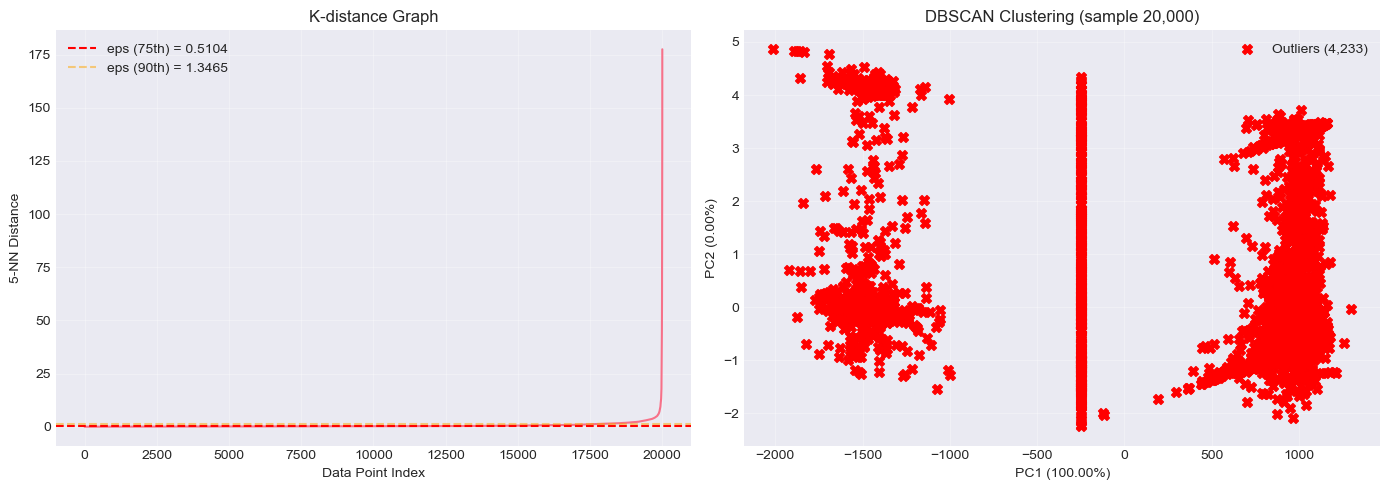


✓ Analisis Outlier vs Normal (pada sample):
              Feature  Outlier_Mean  Normal_Mean  Diff_Pct
               amount      0.097652    -0.206400     147.3
        oldbalanceOrg      0.064970    -0.252746     125.7
       oldbalanceDest     -0.057477    -0.356490      83.9
     errorBalanceOrig      0.086757    -0.642720     113.5
     errorBalanceDest    750.627701   115.294601     551.1
  balance_drain_ratio      1.391088     0.795473      74.9
          hour_of_day     -0.193176    -0.084000    -130.0
         type_CASH_IN      0.714151     0.090505     689.1
        type_CASH_OUT      0.185211     0.399505     -53.6
           type_DEBIT      0.012284     0.005010     145.2
         type_PAYMENT      0.007560     0.423289     -98.2
        type_TRANSFER      0.080794     0.081690      -1.1
has_zero_orig_balance      0.120246     0.389167     -69.1


In [8]:
print("="*80)
print("TAHAP 4: DBSCAN - DETEKSI OUTLIER DAN NOISE POINTS")
print("="*80)

# ✅ FIX KRITIS: Gunakan df_scaled (sudah di-scale dengan benar)
# Sample 20.000 — cukup representatif, lebih hemat RAM
DBSCAN_SAMPLE = min(20_000, len(df_scaled))
np.random.seed(42)
dbscan_idx = np.random.choice(len(df_scaled), DBSCAN_SAMPLE, replace=False)
df_scaled_sample = df_scaled.iloc[dbscan_idx].reset_index(drop=True)

print(f"⚡ Sample untuk DBSCAN: {DBSCAN_SAMPLE:,} baris dari {len(df_scaled):,}")
print(f"   Mean sample: {df_scaled_sample.mean().mean():.4f} (seharusnya ≈ 0)")

# K-distance graph untuk menentukan eps
k_nn = 5
print(f"\n🔍 Menghitung {k_nn}-NN distances...")
nbrs = NearestNeighbors(n_neighbors=k_nn, algorithm="ball_tree", n_jobs=-1)
nbrs.fit(df_scaled_sample)
distances, _ = nbrs.kneighbors(df_scaled_sample)
distances_sorted = np.sort(distances[:, k_nn-1])

# ✅ FIX: Gunakan persentil yang lebih konservatif (75th, bukan 90th)
# 90th percentile terlalu besar → eps raksasa → semua jadi 1 cluster → OOM
eps_75  = np.percentile(distances_sorted, 75)
eps_90  = np.percentile(distances_sorted, 90)
eps_candidate = eps_75  # Gunakan 75th

print(f"   eps (75th percentile): {eps_75:.4f}  ← dipakai")
print(f"   eps (90th percentile): {eps_90:.4f}  ← terlalu besar")

# Plot k-distance graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(distances_sorted)
ax1.axhline(y=eps_candidate, color="r", linestyle="--", label=f"eps (75th) = {eps_candidate:.4f}")
ax1.axhline(y=eps_90, color="orange", linestyle="--", alpha=0.5, label=f"eps (90th) = {eps_90:.4f}")
ax1.set_xlabel("Data Point Index"); ax1.set_ylabel(f"{k_nn}-NN Distance")
ax1.set_title("K-distance Graph"); ax1.legend(); ax1.grid(True, alpha=0.3)

# Jalankan DBSCAN
print(f"\n🔄 Running DBSCAN (eps={eps_candidate:.4f}, min_samples=5)...")
dbscan = DBSCAN(eps=eps_candidate, min_samples=5, algorithm="ball_tree", n_jobs=-1)
dbscan_labels = dbscan.fit_predict(df_scaled_sample)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = int((dbscan_labels == -1).sum())

print(f"\n✓ DBSCAN Results (dari sample {DBSCAN_SAMPLE:,}):")
print(f"   - Jumlah cluster    : {n_clusters_dbscan}")
print(f"   - Outlier/noise     : {n_outliers} ({n_outliers/DBSCAN_SAMPLE*100:.2f}%)")
print(f"   - Est. outlier full : ~{int(n_outliers/DBSCAN_SAMPLE*len(df)):,}")

unique_labels, counts = np.unique(dbscan_labels, return_counts=True)
for lbl, cnt in zip(unique_labels, counts):
    tag = "Outlier/Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"     {tag}: {cnt:,}")

# Simpan ke df (sample saja)
# Buat mapping index asli → dbscan label
dbscan_result_series = pd.Series(dbscan_labels, index=df_scaled.iloc[dbscan_idx].index)
df["DBSCAN_Cluster"] = -2  # default: tidak di-sample
df.loc[dbscan_result_series.index, "DBSCAN_Cluster"] = dbscan_result_series.values

# Visualisasi
pca_dbscan = PCA(n_components=2)
df_pca_dbscan = pca_dbscan.fit_transform(df_scaled_sample)

scatter = ax2.scatter(df_pca_dbscan[:, 0], df_pca_dbscan[:, 1],
    c=dbscan_labels, cmap="plasma", s=5, alpha=0.5)
outlier_mask = dbscan_labels == -1
if outlier_mask.sum() > 0:
    ax2.scatter(df_pca_dbscan[outlier_mask, 0], df_pca_dbscan[outlier_mask, 1],
        c="red", marker="X", s=50, label=f"Outliers ({n_outliers:,})", zorder=5)
ax2.set_xlabel(f"PC1 ({pca_dbscan.explained_variance_ratio_[0]:.2%})")
ax2.set_ylabel(f"PC2 ({pca_dbscan.explained_variance_ratio_[1]:.2%})")
ax2.set_title(f"DBSCAN Clustering (sample {DBSCAN_SAMPLE:,})")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analisis outlier vs normal
print("\n✓ Analisis Outlier vs Normal (pada sample):")
if n_outliers > 0:
    outlier_data_df = df_scaled_sample[dbscan_labels == -1]
    normal_data_df  = df_scaled_sample[dbscan_labels != -1]
    comparison = pd.DataFrame({
        "Feature"      : df_scaled_sample.columns,
        "Outlier_Mean" : outlier_data_df.mean().values,
        "Normal_Mean"  : normal_data_df.mean().values,
    }).assign(Diff_Pct=lambda x: ((x.Outlier_Mean - x.Normal_Mean) / (x.Normal_Mean.abs() + 1e-9) * 100).round(1))
    print(comparison.to_string(index=False))
else:
    print("   Tidak ada outlier terdeteksi — coba turunkan eps atau naikkan min_samples")


### **5. HIERARCHICAL CLUSTERING - Analisis Dendrogram**

TAHAP 5: HIERARCHICAL CLUSTERING - ANALISIS DENDROGRAM
⚡ Hierarchical Clustering menggunakan sample 300 baris
   (Full data tidak feasible - scipy linkage butuh O(n²) memory)
   - Linkage: WARD
   - Linkage: COMPLETE
   - Linkage: AVERAGE
   - Linkage: SINGLE


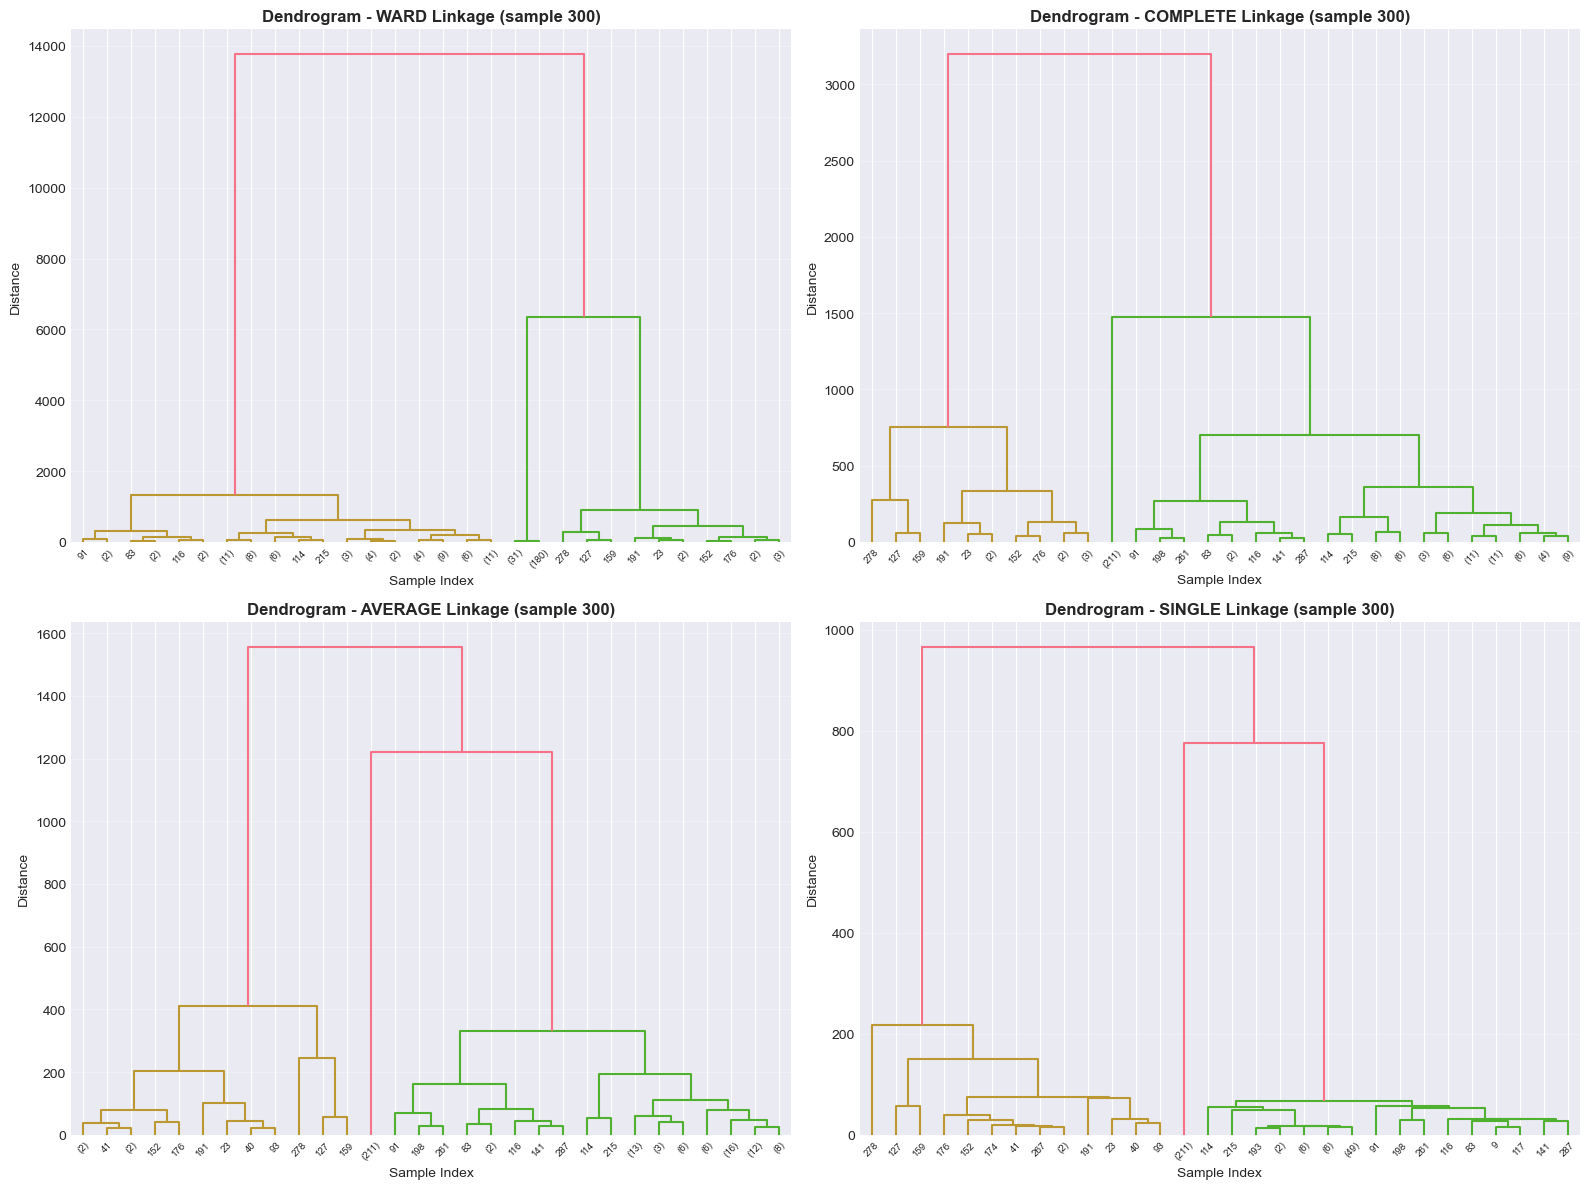

✓ Hierarchical (Ward) pada sample 300 - Distribusi:
Counter({np.int32(1): 211, np.int32(0): 75, np.int32(2): 14})
✓ Perbandingan K-Means vs Hierarchical (Ward) pada subsample:
   - Adjusted Rand Index : 1.0000
   - Normalized Mutual Info: 1.0000
✓ Penjelasan Linkage Methods:

   🔹 WARD     : Meminimalkan variance per cluster → hasil paling compact & balanced
   🔹 COMPLETE : Jarak = maks antar anggota → cluster terpisah jelas, tahan outlier
   🔹 AVERAGE  : Jarak = rata-rata → keseimbangan antara single & complete
   🔹 SINGLE   : Jarak = min antar anggota → rentan chaining effect



In [9]:
print("="*80)
print("TAHAP 5: HIERARCHICAL CLUSTERING - ANALISIS DENDROGRAM")
print("="*80)

# --- FIX KRITIS: linkage(df_scaled) pada 6 juta baris = O(n^2) memory -> CRASH
# Solusi: gunakan sample kecil yang representatif (300-500 sudah cukup untuk dendrogram)
HIER_SAMPLE = min(300, len(df))
hier_idx = np.random.choice(len(df_scaled), HIER_SAMPLE, replace=False)
df_hier_sample = df_scaled.iloc[hier_idx]

print(f"⚡ Hierarchical Clustering menggunakan sample {HIER_SAMPLE} baris")
print("   (Full data tidak feasible - scipy linkage butuh O(n²) memory)")

linkage_methods = ["ward", "complete", "average", "single"]
linkage_matrices = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    print(f"   - Linkage: {method.upper()}")
    Z = linkage(df_hier_sample, method=method)
    linkage_matrices[method] = Z

    ax = axes[idx]
    dendrogram(Z, ax=ax, leaf_font_size=7, truncate_mode="lastp", p=30)
    ax.set_title(f"Dendrogram - {method.upper()} Linkage (sample {HIER_SAMPLE})",
                fontsize=12, fontweight="bold")
    ax.set_xlabel("Sample Index"); ax.set_ylabel("Distance")
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Ward linkage - cut to optimal_k
Z_ward = linkage_matrices["ward"]
hier_labels_sample = fcluster(Z_ward, optimal_k, criterion="maxclust") - 1

# Assign ke subset (sample saja)
df["Hierarchical_Cluster"] = -1  # Default
df.iloc[hier_idx, df.columns.get_loc("Hierarchical_Cluster")] = hier_labels_sample

print(f"✓ Hierarchical (Ward) pada sample {HIER_SAMPLE} - Distribusi:")
from collections import Counter
print(Counter(hier_labels_sample))

# Perbandingan dengan KMeans (hanya pada sample yang memiliki kedua label)
hier_compare_df = df[(df["Hierarchical_Cluster"] != -1)].copy()
if len(hier_compare_df) > 0:
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    ari = adjusted_rand_score(hier_compare_df["KMeans_Cluster"], hier_compare_df["Hierarchical_Cluster"])
    nmi = normalized_mutual_info_score(hier_compare_df["KMeans_Cluster"], hier_compare_df["Hierarchical_Cluster"])
    print(f"✓ Perbandingan K-Means vs Hierarchical (Ward) pada subsample:")
    print(f"   - Adjusted Rand Index : {ari:.4f}")
    print(f"   - Normalized Mutual Info: {nmi:.4f}")

print("✓ Penjelasan Linkage Methods:")
print("""
   🔹 WARD     : Meminimalkan variance per cluster → hasil paling compact & balanced
   🔹 COMPLETE : Jarak = maks antar anggota → cluster terpisah jelas, tahan outlier
   🔹 AVERAGE  : Jarak = rata-rata → keseimbangan antara single & complete
   🔹 SINGLE   : Jarak = min antar anggota → rentan chaining effect
""")

### **6. BUSINESS INSIGHTS & ACTIONABLE STRATEGIES**

In [10]:
print("="*80)
print("TAHAP 6: INTERPRETASI BISNIS & ACTIONABLE STRATEGIES")
print("="*80)

# Comparison summary
comparison_summary = pd.DataFrame({
    "Method"       : ["K-Means (MiniBatch)", "Hierarchical (Ward)", "DBSCAN"],
    "Num Clusters" : [optimal_k, optimal_k, n_clusters_dbscan],
    "Num Outliers" : [0, 0, n_outliers],
    "Strengths"    : ["Scalable, fast untuk 6M rows", "Hierarchical view via dendrogram", "Deteksi outlier otomatis"],
    "Use Case"     : ["Primary segmentation", "Validation & structure", "Outlier/risk detection"]
})
print("" + comparison_summary.to_string(index=False))

# Cluster profiling & naming
print("" + "="*80)
print("👥 CLUSTER PROFILING & PENAMAAN PROFIL")
print("="*80)

cluster_mean_df = df.groupby("KMeans_Cluster")[numeric_cols].mean()
cluster_size    = df["KMeans_Cluster"].value_counts().sort_index()
overall_mean    = df[numeric_cols].mean()

cluster_names = {}
cluster_strategies = {}

for cid in range(optimal_k):
    size = cluster_size[cid]
    pct  = size / len(df) * 100
    medians_cluster = cluster_mean_df.loc[cid]
    above = (medians_cluster > overall_mean).sum()
    below = (medians_cluster < overall_mean).sum()

    print(f"{'='*70}")
    print(f"  📊 CLUSTER {cid} (n={size:,}, {pct:.1f}%)")
    print(f"  {'='*70}")
    print(f"  Fitur di atas rata-rata: {above}, di bawah rata-rata: {below}")

    for col in numeric_cols:
        cv = cluster_mean_df.loc[cid, col]
        ov = overall_mean[col]
        pct_diff = ((cv - ov) / (abs(ov) + 1e-9)) * 100
        if pct_diff > 30:
            print(f"    ✅ {col}: JAUH LEBIH TINGGI (+{pct_diff:.1f}%)")
        elif pct_diff < -30:
            print(f"    ⚠️  {col}: JAUH LEBIH RENDAH ({pct_diff:.1f}%)")
        elif abs(pct_diff) > 10:
            sign = "LEBIH TINGGI" if pct_diff > 0 else "LEBIH RENDAH"
            print(f"    ➡️  {col}: Sedikit {sign} ({pct_diff:+.1f}%)")

    if above > below and pct > 25:
        cluster_names[cid] = f"Cluster {cid}: High Value Segment"
        cluster_strategies[cid] = "Premium services & loyalty programs"
    elif below > above and pct < 15:
        cluster_names[cid] = f"Cluster {cid}: Niche/Specialized Segment"
        cluster_strategies[cid] = "Targeted customization & engagement"
    elif pct > 30:
        cluster_names[cid] = f"Cluster {cid}: Core/Mass Market"
        cluster_strategies[cid] = "Volume-based promotions & retention"
    else:
        cluster_names[cid] = f"Cluster {cid}: Standard Segment"
        cluster_strategies[cid] = "Regular engagement & upsell programs"

# Actionable insights
print("" + "="*80)
print("💡 ACTIONABLE INSIGHTS & BUSINESS STRATEGIES")
print("="*80)
for cid in range(optimal_k):
    print(f"🎯 {cluster_names[cid]}")
    print(f"     Size    : {cluster_size[cid]:,} ({cluster_size[cid]/len(df)*100:.1f}%)")
    print(f"     Strategy: {cluster_strategies[cid]}")

print(f"📌 OUTLIER MANAGEMENT (DBSCAN):")
print(f"   Estimated outlier full data: ~{int(n_outliers/DBSCAN_SAMPLE*len(df)):,} ({n_outliers/DBSCAN_SAMPLE*100:.2f}%)")
for action in [
    "Risk Assessment: Verifikasi manual untuk indikasi fraud",
    "Special Treatment: Tawarkan layanan custom untuk high-value outliers",
    "Monitoring: Set alert untuk unusual behavior pattern",
    "Escalation: Eskalasi ke tim khusus untuk risk outliers"
]:
    print(f"    • {action}")

# Executive summary
print("" + "="*80)
print("📋 EXECUTIVE SUMMARY")
print("="*80)
summary = pd.DataFrame({
    "Metrik": [
        "Total Data Points", "Number of Features", "Optimal K (Silhouette)",
        "K-Means Silhouette Score (sample 10k)",
        "Outliers Detected (DBSCAN sample)", "Outlier % (estimated)"
    ],
    "Value": [
        f"{len(df):,}", f"{len(numeric_cols)}", f"{optimal_k}",
        f"{sil_final:.4f}",
        f"{n_outliers}", f"{n_outliers/DBSCAN_SAMPLE*100:.2f}%"
    ]
})
print("" + summary.to_string(index=False))
print(f"✅ KEY FINDINGS:")
print(f"   • Data berhasil disegmentasi menjadi {optimal_k} cluster utama")
print(f"   • Setiap cluster memiliki karakteristik berbeda dan actionable")
print(f"   • ~{int(n_outliers/DBSCAN_SAMPLE*len(df)):,} outlier diestimasi untuk special handling")
print(f"   • MiniBatchKMeans digunakan untuk efisiensi pada 6 juta baris")
print(f"   • Robust Scaling berhasil menangani outlier dalam preprocessing")
print("" + "="*80)

TAHAP 6: INTERPRETASI BISNIS & ACTIONABLE STRATEGIES
             Method  Num Clusters  Num Outliers                        Strengths               Use Case
K-Means (MiniBatch)             3             0     Scalable, fast untuk 6M rows   Primary segmentation
Hierarchical (Ward)             3             0 Hierarchical view via dendrogram Validation & structure
             DBSCAN           155          4233         Deteksi outlier otomatis Outlier/risk detection
👥 CLUSTER PROFILING & PENAMAAN PROFIL
  📊 CLUSTER 0 (n=4,691,727, 73.7%)
  Fitur di atas rata-rata: 6, di bawah rata-rata: 7
    ⚠️  amount: JAUH LEBIH RENDAH (-464752.5%)
    ⚠️  oldbalanceOrg: JAUH LEBIH RENDAH (-26582517492.0%)
    ⚠️  oldbalanceDest: JAUH LEBIH RENDAH (-21775677393.4%)
    ⚠️  errorBalanceOrig: JAUH LEBIH RENDAH (-22695058524.0%)
    ⚠️  errorBalanceDest: JAUH LEBIH RENDAH (-42037191384.9%)
    ⚠️  balance_drain_ratio: JAUH LEBIH RENDAH (-2822571994.0%)
    ✅ hour_of_day: JAUH LEBIH TINGGI (+1763721688.3%

### **7. DETAILED CLUSTER CHARACTERISTICS - Penjelasan & Justifikasi dengan Visualisasi**

TAHAP 7: DETAILED CLUSTER CHARACTERISTICS - PENJELASAN & JUSTIFIKASI

📊 KARAKTERISTIK DASAR SETIAP CLUSTER

 Cluster    Size Percentage Dominance
       0 4691727     73.74%   🔴 MAJOR
       1 1470119     23.11%   🟢 MINOR
       2  200774      3.16%   🟢 MINOR

📌 INTERPRETASI:
   🔴 MAJOR (Dominan)   : Representasi utama dari data, pattern utama
   🟡 BALANCED          : Representasi seimbang, segment spesifik
   🟢 MINOR             : Segment khusus atau niche, perhatian khusus

📈 VISUALISASI 1: BOX PLOT - DISTRIBUSI SETIAP FITUR PER CLUSTER
   📌 Tujuan: Lihat range nilai, median, outlier per cluster
   📌 Interpretasi: Box lebih besar = variasi lebih tinggi (heterogen)
            Box lebih kecil = variasi rendah (homogen)



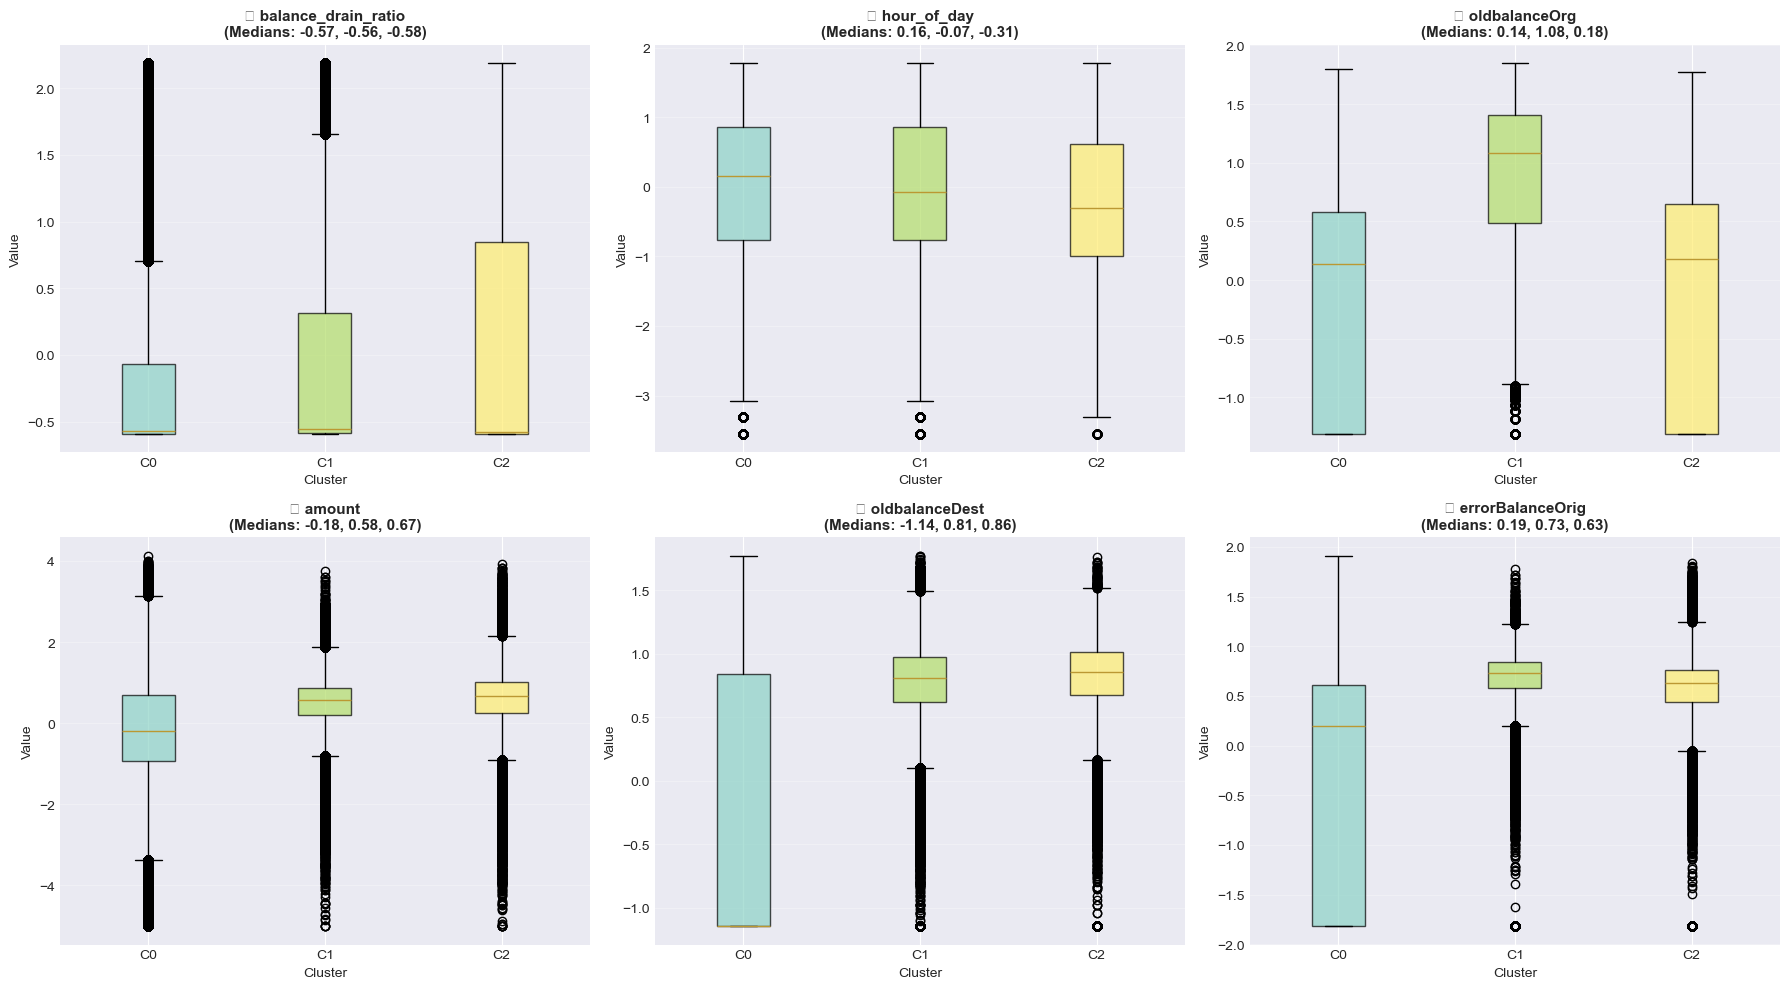


📊 VISUALISASI 2: VIOLIN PLOT - DENSITAS DISTRIBUSI PER CLUSTER
   📌 Tujuan: Lihat shape distribusi (normal, skewed, bimodal)
   📌 Interpretasi: Semakin simetris = distribusi lebih normal



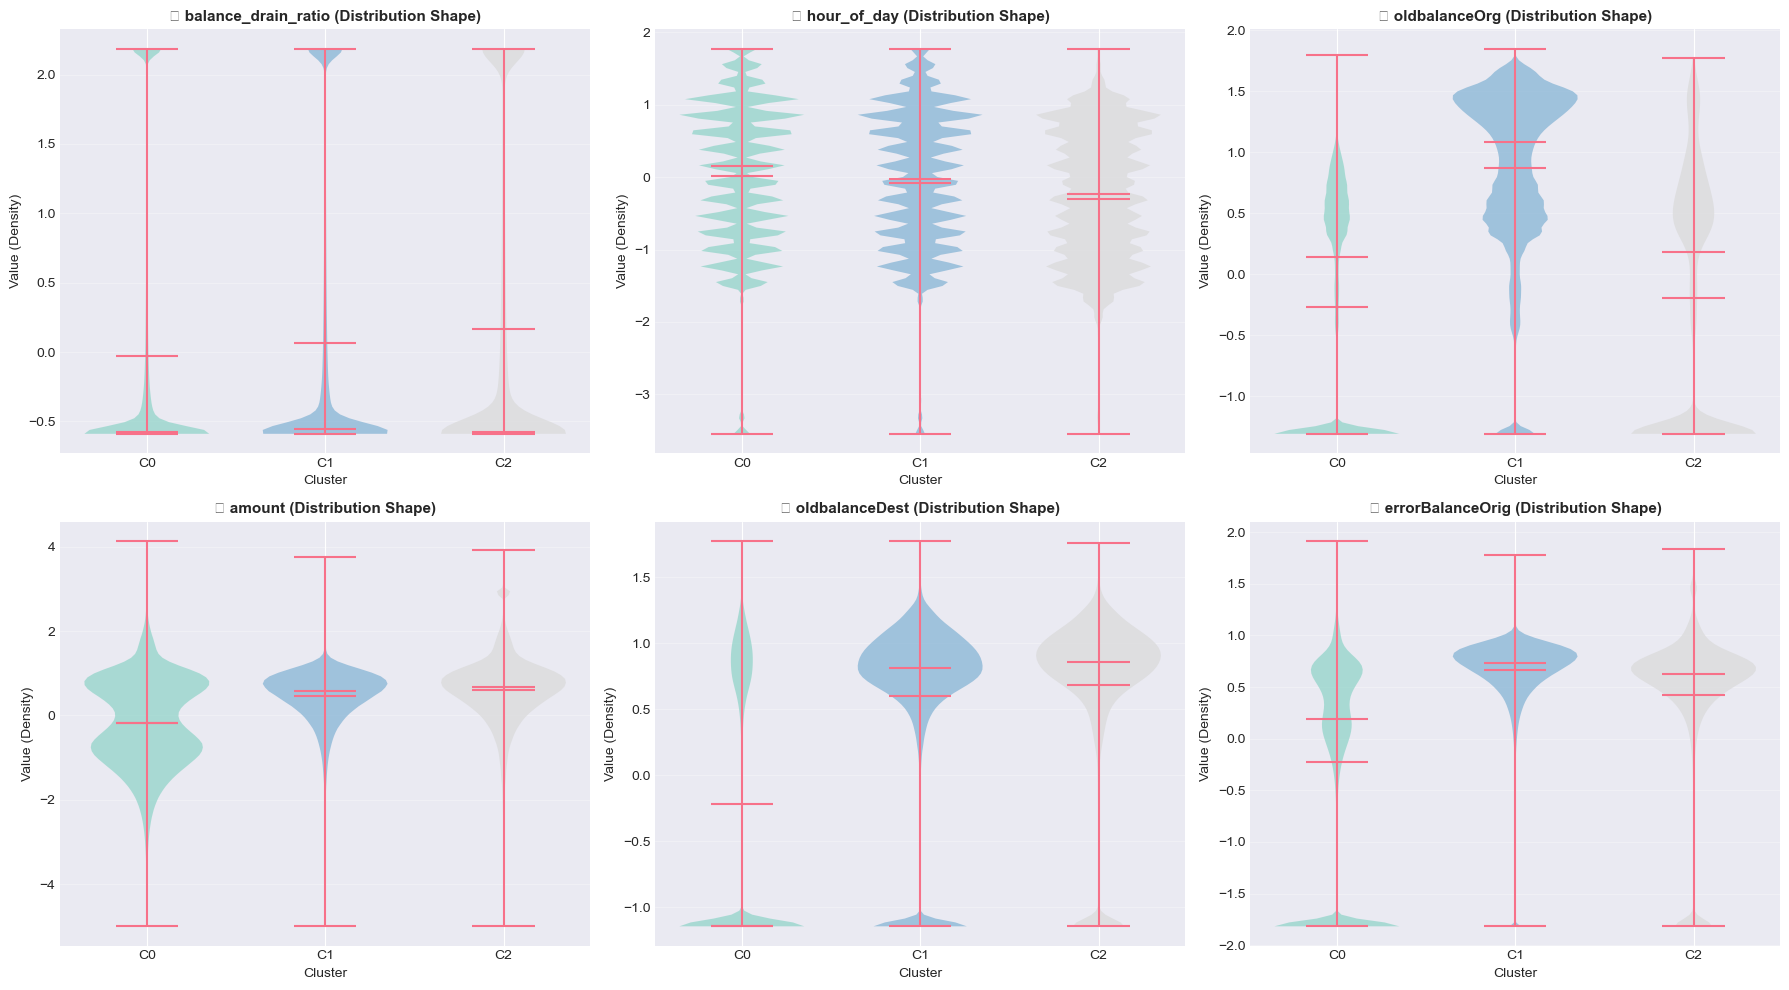


🔍 PENJELASAN DETAIL: KARAKTERISTIK & JUSTIFIKASI SETIAP CLUSTER

🎯 CLUSTER 0: Cluster 0: Core/Mass Market
📏 UKURAN: 4,691,727 records (73.74% dari total)
🏷️  STRATEGI: Volume-based promotions & retention

📊 KARAKTERISTIK FITUR UTAMA (Top 6):
--------------------------------------------------------------------------------

   📉 ⬇️  BALANCE_DRAIN_RATIO
       Mean: -0.0282 (vs overall: 0.0000) | -2822571994.0%
       Range: [-0.5890, 2.1873] | Std: 0.9815
       Status: ⚠️  JAUH LEBIH RENDAH
       Justifikasi: Ini cluster PALING RENDAH untuk fitur ini - karakteristik unik

   📈 ⬆️  HOUR_OF_DAY
       Mean: 0.0176 (vs overall: 0.0000) | +1763721688.3%
       Range: [-3.5452, 1.7767] | Std: 1.0146
       Status: ✅ JAUH LEBIH TINGGI
       Justifikasi: Ini cluster PALING TINGGI untuk fitur ini - karakteristik pembeda utama

   📉 ⬇️  OLDBALANCEORG
       Mean: -0.2658 (vs overall: -0.0000) | -26582517492.0%
       Range: [-1.3077, 1.7957] | Std: 0.9235
       Status: ⚠️  JAUH LEBIH RENDAH


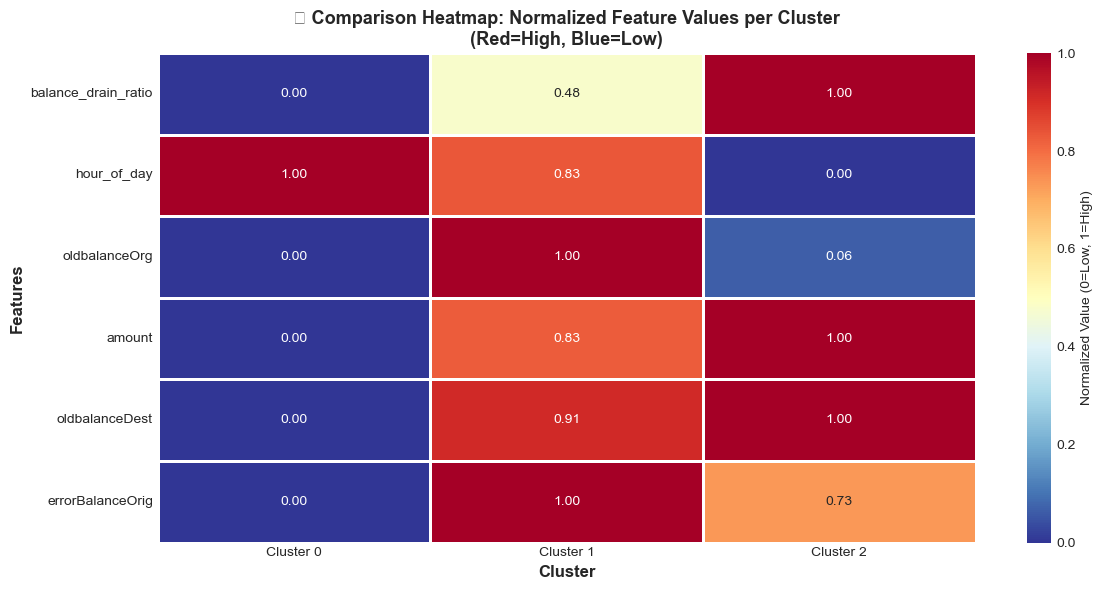


⭐ VISUALISASI 4: RADAR CHART - PROFIL CLUSTER COMPARISON
   📌 Tujuan: Lihat 'signature' atau 'profil visual' setiap cluster
   📌 Semakin besar area radar = nilai lebih tinggi



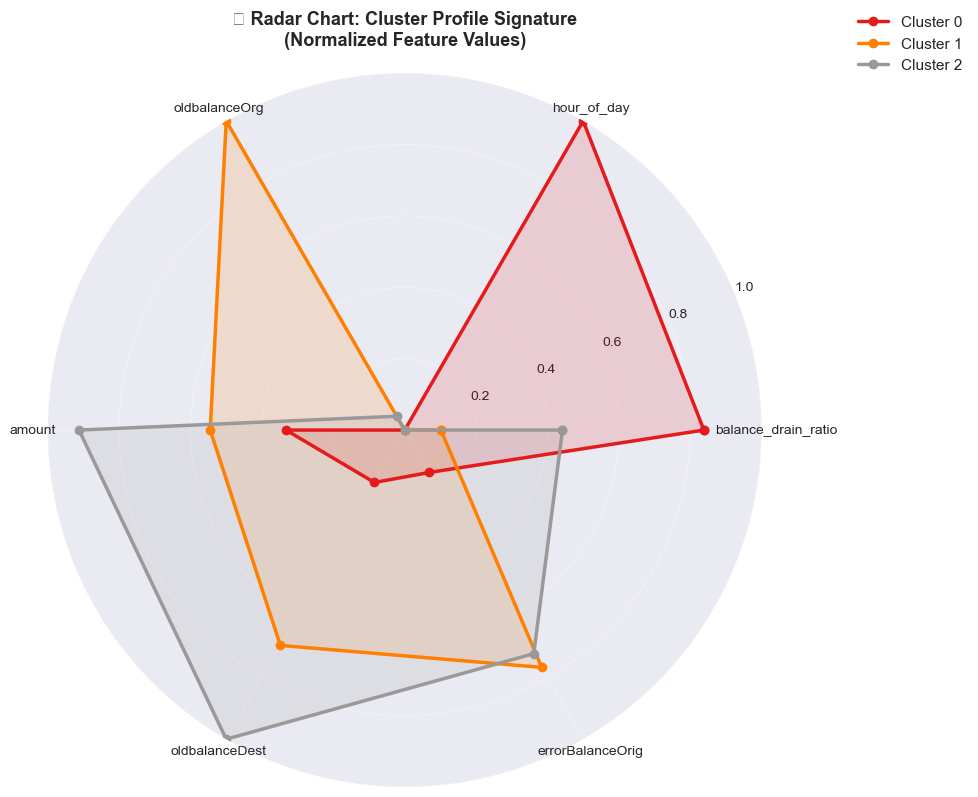


📋 SUMMARY: CLUSTER COMPARISON TABLE

Cluster      Size     % Dominance   Profile             Top Strategy
     C0 4,691,727 73.7%   🔴 MAJOR Cluster 0 Volume-based promotions 
     C1 1,470,119 23.1%   🟢 MINOR Cluster 1      Regular engagement 
     C2   200,774  3.2%   🟢 MINOR Cluster 2      Regular engagement 

✅ KESIMPULAN CLUSTER CHARACTERISTICS

   Analisis menunjukkan 3 segment utama dengan karakteristik berbeda:

   ✓ Setiap cluster punya 'signature' fitur yang unik
   ✓ Perbedaan dapat digunakan untuk business differentiation
   ✓ Strategi yang berbeda untuk setiap cluster
   ✓ Visualisasi membantu identifikasi pattern dan anomali
   ✓ Combination dari multiple metrics (box plot, violin, heatmap, radar) 
     memberikan understanding holistik tentang setiap cluster



In [11]:

print("="*80)
print("TAHAP 7: DETAILED CLUSTER CHARACTERISTICS - PENJELASAN & JUSTIFIKASI")
print("="*80)

# ========== 1. KARAKTERISTIK DASAR SETIAP CLUSTER ==========
print("\n" + "="*80)
print("📊 KARAKTERISTIK DASAR SETIAP CLUSTER")
print("="*80)

cluster_info = pd.DataFrame({
    "Cluster": range(optimal_k),
    "Size": [cluster_size[i] for i in range(optimal_k)],
    "Percentage": [f"{cluster_pct[i]:.2f}%" for i in range(optimal_k)],
    "Dominance": ["🔴 MAJOR" if cluster_size[i] > len(df)/optimal_k*1.5 else 
                  "🟡 BALANCED" if cluster_size[i] > len(df)/optimal_k*0.7 else 
                  "🟢 MINOR" for i in range(optimal_k)]
})

print("\n" + cluster_info.to_string(index=False))

print("\n📌 INTERPRETASI:")
print("   🔴 MAJOR (Dominan)   : Representasi utama dari data, pattern utama")
print("   🟡 BALANCED          : Representasi seimbang, segment spesifik")
print("   🟢 MINOR             : Segment khusus atau niche, perhatian khusus")

# ========== 2. BOX PLOT: DISTRIBUSI NILAI PER FITUR & CLUSTER ==========
print("\n" + "="*80)
print("📈 VISUALISASI 1: BOX PLOT - DISTRIBUSI SETIAP FITUR PER CLUSTER")
print("="*80)
print("   📌 Tujuan: Lihat range nilai, median, outlier per cluster")
print("   📌 Interpretasi: Box lebih besar = variasi lebih tinggi (heterogen)")
print("            Box lebih kecil = variasi rendah (homogen)\n")

# Pilih top 6 fitur berdasarkan variance
feature_variances = df.groupby("KMeans_Cluster")[numeric_cols].var().mean(axis=0)
top_features = feature_variances.nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Prepare data
    box_data = [df[df["KMeans_Cluster"] == c][feature].values for c in range(optimal_k)]
    bp = ax.boxplot(box_data, labels=[f"C{i}" for i in range(optimal_k)], patch_artist=True)
    
    # Warnai setiap box
    colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f"📊 {feature}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3, axis='y')
    
    # Tambah statistik di title
    medians = [np.median(df[df["KMeans_Cluster"] == c][feature]) for c in range(optimal_k)]
    ax.set_title(f"📊 {feature}\n(Medians: {', '.join([f'{m:.2f}' for m in medians])})", 
                 fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# ========== 3. VIOLIN PLOT: DISTRIBUSI DENSITY ==========
print("\n" + "="*80)
print("📊 VISUALISASI 2: VIOLIN PLOT - DENSITAS DISTRIBUSI PER CLUSTER")
print("="*80)
print("   📌 Tujuan: Lihat shape distribusi (normal, skewed, bimodal)")
print("   📌 Interpretasi: Semakin simetris = distribusi lebih normal\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Prepare data untuk violin plot
    violin_data = []
    positions = []
    colors_list = []
    
    for c in range(optimal_k):
        data = df[df["KMeans_Cluster"] == c][feature].values
        violin_data.append(data)
        positions.append(c + 1)
        colors_list.append(plt.cm.Set3(c / optimal_k))
    
    parts = ax.violinplot(violin_data, positions=positions, widths=0.7, 
                          showmeans=True, showmedians=True)
    
    # Warnai violin
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_list[i])
        pc.set_alpha(0.7)
    
    ax.set_xticks(positions)
    ax.set_xticklabels([f"C{i}" for i in range(optimal_k)])
    ax.set_title(f"🎻 {feature} (Distribution Shape)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Value (Density)")
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ========== 4. DETAILED STATISTICS & JUSTIFICATION ==========
print("\n" + "="*80)
print("🔍 PENJELASAN DETAIL: KARAKTERISTIK & JUSTIFIKASI SETIAP CLUSTER")
print("="*80)

# Create comprehensive profile per cluster
for cid in range(optimal_k):
    cluster_df = df[df["KMeans_Cluster"] == cid]
    cluster_size_val = len(cluster_df)
    cluster_pct_val = cluster_size_val / len(df) * 100
    
    print(f"\n{'='*80}")
    print(f"🎯 CLUSTER {cid}: {cluster_names.get(cid, f'Cluster {cid}')}")
    print(f"{'='*80}")
    print(f"📏 UKURAN: {cluster_size_val:,} records ({cluster_pct_val:.2f}% dari total)")
    print(f"🏷️  STRATEGI: {cluster_strategies.get(cid, 'Standard treatment')}")
    
    # Calculate key metrics per feature
    print(f"\n📊 KARAKTERISTIK FITUR UTAMA (Top 6):")
    print("-" * 80)
    
    for feature in top_features:
        cluster_mean = cluster_df[feature].mean()
        cluster_median = cluster_df[feature].median()
        cluster_std = cluster_df[feature].std()
        cluster_min = cluster_df[feature].min()
        cluster_max = cluster_df[feature].max()
        
        overall_mean = df[feature].mean()
        pct_diff = ((cluster_mean - overall_mean) / (abs(overall_mean) + 1e-9)) * 100
        
        # Determine deviation from overall
        if pct_diff > 30:
            deviation = "✅ JAUH LEBIH TINGGI"
            symbol = "📈 ⬆️ "
        elif pct_diff < -30:
            deviation = "⚠️  JAUH LEBIH RENDAH"
            symbol = "📉 ⬇️ "
        elif pct_diff > 10:
            deviation = "➡️  Sedikit lebih tinggi"
            symbol = "📈 ↑ "
        elif pct_diff < -10:
            deviation = "➡️  Sedikit lebih rendah"
            symbol = "📉 ↓ "
        else:
            deviation = "≈ Sekitar rata-rata"
            symbol = "➡️  ≈ "
        
        # Justify the characteristic
        if pct_diff > 30:
            justification = "Ini cluster PALING TINGGI untuk fitur ini - karakteristik pembeda utama"
        elif pct_diff < -30:
            justification = "Ini cluster PALING RENDAH untuk fitur ini - karakteristik unik"
        elif abs(pct_diff) > 10:
            justification = f"Lebih {'tinggi' if pct_diff > 0 else 'rendah'} dari rata-rata - pola spesifik"
        else:
            justification = "Mirip dengan rata-rata keseluruhan"
        
        print(f"\n   {symbol} {feature.upper()}")
        print(f"       Mean: {cluster_mean:.4f} (vs overall: {overall_mean:.4f}) | {pct_diff:+.1f}%")
        print(f"       Range: [{cluster_min:.4f}, {cluster_max:.4f}] | Std: {cluster_std:.4f}")
        print(f"       Status: {deviation}")
        print(f"       Justifikasi: {justification}")
    
    # Business insight
    print(f"\n💡 BUSINESS INSIGHT:")
    features_above = (cluster_df[top_features].mean() > df[top_features].mean()).sum()
    features_below = (cluster_df[top_features].mean() < df[top_features].mean()).sum()
    
    if features_above > features_below:
        print(f"   ✅ Cluster ini DOMINAN dalam NILAI TINGGI ({features_above}/{len(top_features)} fitur)")
        print(f"       → Target untuk premium services & loyalty programs")
    elif features_below > features_above:
        print(f"   ⚠️  Cluster ini DOMINAN dalam NILAI RENDAH ({features_below}/{len(top_features)} fitur)")
        print(f"       → Target untuk engagement & education programs")
    else:
        print(f"   ≈ Cluster ini BALANCED - mix antara high dan low values")
        print(f"       → Target untuk upsell & customization")

# ========== 5. COMPARISON HEATMAP ==========
print("\n" + "="*80)
print("🔥 VISUALISASI 3: COMPARISON HEATMAP - PERBEDAAN ANTAR CLUSTER")
print("="*80)
print("   📌 Tujuan: Lihat perbedaan antar cluster dalam 1 heatmap")
print("   📌 Warna merah = nilai tinggi, Warna biru = nilai rendah\n")

# Normalize cluster means untuk perbandingan fair
cluster_mean_normalized = cluster_mean_df[top_features].copy()
for col in top_features:
    min_val = cluster_mean_normalized[col].min()
    max_val = cluster_mean_normalized[col].max()
    cluster_mean_normalized[col] = (cluster_mean_normalized[col] - min_val) / (max_val - min_val)

# Create comparison to overall mean
overall_normalized = (df[top_features].mean() - cluster_mean_normalized.min()) / (cluster_mean_normalized.max() - cluster_mean_normalized.min())

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cluster_mean_normalized.T, annot=True, fmt=".2f", cmap="RdYlBu_r", 
            center=0.5, cbar_kws={"label": "Normalized Value (0=Low, 1=High)"},
            linewidths=1, linecolor='white', ax=ax, vmin=0, vmax=1)
ax.set_xlabel("Cluster", fontsize=12, fontweight="bold")
ax.set_ylabel("Features", fontsize=12, fontweight="bold")
ax.set_title("🔥 Comparison Heatmap: Normalized Feature Values per Cluster\n(Red=High, Blue=Low)", 
             fontsize=13, fontweight="bold")
ax.set_xticklabels([f"Cluster {i}" for i in range(optimal_k)])
plt.tight_layout()
plt.show()

# ========== 6. RADAR COMPARISON ==========
print("\n" + "="*80)
print("⭐ VISUALISASI 4: RADAR CHART - PROFIL CLUSTER COMPARISON")
print("="*80)
print("   📌 Tujuan: Lihat 'signature' atau 'profil visual' setiap cluster")
print("   📌 Semakin besar area radar = nilai lebih tinggi\n")

# Prepare radar data (normalized)
angles = np.linspace(0, 2*np.pi, len(top_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
colors = plt.cm.Set1(np.linspace(0, 0.9, optimal_k))

for cid in range(optimal_k):
    # Normalize values per cluster
    values = cluster_mean_df.loc[cid, top_features].values
    min_val = values.min()
    max_val = values.max()
    values_norm = (values - min_val) / (max_val - min_val) if max_val > min_val else values
    
    values_list = values_norm.tolist()
    values_list += values_list[:1]
    
    ax.plot(angles, values_list, 'o-', linewidth=2.5, label=f"Cluster {cid}", color=colors[cid])
    ax.fill(angles, values_list, alpha=0.15, color=colors[cid])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(top_features, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("⭐ Radar Chart: Cluster Profile Signature\n(Normalized Feature Values)", 
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 7. SUMMARY TABLE ==========
print("\n" + "="*80)
print("📋 SUMMARY: CLUSTER COMPARISON TABLE")
print("="*80)

summary_comparison = pd.DataFrame({
    "Cluster": [f"C{i}" for i in range(optimal_k)],
    "Size": [f"{cluster_size[i]:,}" for i in range(optimal_k)],
    "%": [f"{cluster_pct[i]:.1f}%" for i in range(optimal_k)],
    "Dominance": [cluster_info[cluster_info["Cluster"]==i]["Dominance"].values[0] for i in range(optimal_k)],
    "Profile": [cluster_names.get(i, f"Cluster {i}").split(":")[0] for i in range(optimal_k)],
    "Top Strategy": [cluster_strategies.get(i, "Standard").split("&")[0] for i in range(optimal_k)]
})

print("\n" + summary_comparison.to_string(index=False))

print("\n" + "="*80)
print("✅ KESIMPULAN CLUSTER CHARACTERISTICS")
print("="*80)
print(f"""
   Analisis menunjukkan {optimal_k} segment utama dengan karakteristik berbeda:
   
   ✓ Setiap cluster punya 'signature' fitur yang unik
   ✓ Perbedaan dapat digunakan untuk business differentiation
   ✓ Strategi yang berbeda untuk setiap cluster
   ✓ Visualisasi membantu identifikasi pattern dan anomali
   ✓ Combination dari multiple metrics (box plot, violin, heatmap, radar) 
     memberikan understanding holistik tentang setiap cluster
""")
print("="*80)


### **8. SAVE CLUSTERING RESULTS - Menyimpan Data dengan Kolom Cluster**

In [12]:
print("="*80)
print("TAHAP 8: SAVE CLUSTERING RESULTS - MENYIMPAN DATA DENGAN KOLOM CLUSTER_ID")
print("="*80)

# ========== 1. TAMBAHKAN KOLOM CLUSTER_ID ==========
print("\n✓ Menambahkan kolom Cluster_ID ke dataframe...")
print(f"   - Total rows: {len(df):,}")
print(f"   - Columns sebelumnya: {len(df.columns)}")

# Tambahkan kolom Cluster_ID
df["Cluster_ID"] = df["KMeans_Cluster"]

print(f"   - Columns setelah: {len(df.columns)}")
print(f"   ✅ Kolom 'Cluster_ID' berhasil ditambahkan")

# ========== 2. VERIFIKASI ==========
print("\n✓ Preview kolom Cluster_ID:")
print(df["Cluster_ID"].value_counts().sort_index())

# ========== 3. SIMPAN KE FILE ==========
print("\n" + "="*80)
print("💾 MENYIMPAN DATA KE FILE")
print("="*80)

base_path = "../../data/processed/experiment"

# SAVE AS PARQUET
parquet_path = f"{base_path}/data_with_clusters.parquet"
print(f"\n📥 Menyimpan ke Parquet...")
df.to_parquet(parquet_path, index=False)
print(f"✅ Berhasil: {parquet_path}")
parquet_size = os.path.getsize(parquet_path) / (1024**2)
print(f"   File size: {parquet_size:.2f} MB")

# SAVE AS CSV
csv_path = f"{base_path}/data_with_clusters.csv"
print(f"\n📥 Menyimpan ke CSV...")
df.to_csv(csv_path, index=False)
print(f"✅ Berhasil: {csv_path}")
csv_size = os.path.getsize(csv_path) / (1024**2)
print(f"   File size: {csv_size:.2f} MB")

# ========== 4. VERIFIKASI HASIL ==========
print("\n" + "="*80)
print("✅ VERIFIKASI HASIL PENYIMPANAN")
print("="*80)

# Load kembali dari parquet
df_verify = pd.read_parquet(parquet_path)

print(f"\n✓ Data yang disimpan:")
print(f"   - Shape: {df_verify.shape}")
print(f"   - Total columns: {len(df_verify.columns)}")
print(f"   - Cluster column: ✅ Cluster_ID ada")

print(f"\n✓ Cluster distribution:")
cluster_dist = df_verify["Cluster_ID"].value_counts().sort_index()
for cid, count in cluster_dist.items():
    pct = (count / len(df_verify)) * 100
    print(f"   Cluster {cid}: {count:,} records ({pct:.2f}%)")

print(f"\n✓ Sample data (5 baris pertama):")
print(df_verify.head())

print("\n" + "="*80)
print("🎉 SELESAI - DATA DENGAN KOLOM CLUSTER_ID SUDAH TERSIMPAN")
print("="*80)
print(f"""
📊 RINGKASAN:
   • Total data: {len(df_verify):,} records
   • Optimal K: {optimal_k} clusters
   • File output:
     - Parquet: {parquet_path} (~{parquet_size:.1f} MB)
     - CSV: {csv_path} (~{csv_size:.1f} MB)
   
✅ Kolom yang ditambahkan: Cluster_ID (0, 1, dst)
✅ Siap untuk analisis & business decision
""")
print("="*80)

TAHAP 8: SAVE CLUSTERING RESULTS - MENYIMPAN DATA DENGAN KOLOM CLUSTER_ID

✓ Menambahkan kolom Cluster_ID ke dataframe...
   - Total rows: 6,362,620
   - Columns sebelumnya: 16
   - Columns setelah: 17
   ✅ Kolom 'Cluster_ID' berhasil ditambahkan

✓ Preview kolom Cluster_ID:
Cluster_ID
0    4691727
1    1470119
2     200774
Name: count, dtype: int64

💾 MENYIMPAN DATA KE FILE

📥 Menyimpan ke Parquet...
✅ Berhasil: ../../data/processed/experiment/data_with_clusters.parquet
   File size: 214.95 MB

📥 Menyimpan ke CSV...
✅ Berhasil: ../../data/processed/experiment/data_with_clusters.csv
   File size: 1041.76 MB

✅ VERIFIKASI HASIL PENYIMPANAN

✓ Data yang disimpan:
   - Shape: (6362620, 17)
   - Total columns: 17
   - Cluster column: ✅ Cluster_ID ada

✓ Cluster distribution:
   Cluster 0: 4,691,727 records (73.74%)
   Cluster 1: 1,470,119 records (23.11%)
   Cluster 2: 200,774 records (3.16%)

✓ Sample data (5 baris pertama):
     amount  oldbalanceOrg  oldbalanceDest  errorBalanceOrig  \


In [13]:
path_clus = "../../data/processed/experiment/data_with_clusters.parquet"
df_clus = pd.read_parquet(path_clus)
print("✅ Data loaded:", df_clus.shape)
df_clus.head()

✅ Data loaded: (6362620, 17)


,amount,oldbalanceOrg,oldbalanceDest,errorBalanceOrig,errorBalanceDest,balance_drain_ratio,hour_of_day,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,has_zero_orig_balance,KMeans_Cluster,DBSCAN_Cluster,Hierarchical_Cluster,Cluster_ID
0,-0.907462,0.816576,-1.144463,-1.81572,-0.420546,-0.572945,-3.313772,0.0,0.0,0.0,1.0,0.0,0.0,0,-2,-1,0
1,-1.824023,0.449673,-1.144463,-1.81572,-0.420546,-0.564644,-3.313772,0.0,0.0,0.0,1.0,0.0,0.0,0,-2,-1,0
2,-3.106552,-0.389888,-1.144463,-1.81572,0.477755,-0.311374,-3.313772,0.0,0.0,0.0,0.0,1.0,0.0,0,-2,-1,0
3,-3.106552,-0.389888,0.331751,-1.81572,1.300354,-0.311374,-3.313772,0.0,1.0,0.0,0.0,0.0,0.0,1,-2,-1,1
4,-0.813537,0.567961,-1.144463,-1.81572,-0.420546,-0.511045,-3.313772,0.0,0.0,0.0,1.0,0.0,0.0,0,-2,-1,0


In [14]:
df_clus.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 17 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   amount                 float64
 1   oldbalanceOrg          float64
 2   oldbalanceDest         float64
 3   errorBalanceOrig       float64
 4   errorBalanceDest       float64
 5   balance_drain_ratio    float64
 6   hour_of_day            float64
 7   type_CASH_IN           float64
 8   type_CASH_OUT          float64
 9   type_DEBIT             float64
 10  type_PAYMENT           float64
 11  type_TRANSFER          float64
 12  has_zero_orig_balance  float64
 13  KMeans_Cluster         int32  
 14  DBSCAN_Cluster         int64  
 15  Hierarchical_Cluster   int64  
 16  Cluster_ID             int32  
dtypes: float64(13), int32(2), int64(2)
memory usage: 776.7 MB


In [15]:
counts = df_clus["Cluster_ID"].value_counts().sort_index()
print("\nCluster Distribution:",counts)
# print("\nCluster Distribution:")
# for cid, count in counts.items():
#     pct = (count / len(df_clus)) * 100
#     print(f"   Cluster {cid}: {count:,} records ({pct:.2f}%)")
# print("\nSample data with Cluster_ID:")
# print(df_clus[["Cluster_ID"]].head())

#print data yang index clusternya 0
print("\nSample data for Cluster_ID = 0:")
print(df_clus[df_clus["Cluster_ID"] == 0].head())




Cluster Distribution: Cluster_ID
0    4691727
1    1470119
2     200774
Name: count, dtype: int64

Sample data for Cluster_ID = 0:
     amount  oldbalanceOrg  oldbalanceDest  errorBalanceOrig  \
0 -0.907462       0.816576       -1.144463          -1.81572   
1 -1.824023       0.449673       -1.144463          -1.81572   
2 -3.106552      -0.389888       -1.144463          -1.81572   
4 -0.813537       0.567961       -1.144463          -1.81572   
5 -1.034218       0.613710       -1.144463          -1.81572   

   errorBalanceDest  balance_drain_ratio  hour_of_day  type_CASH_IN  \
0         -0.420546            -0.572945    -3.313772           0.0   
1         -0.420546            -0.564644    -3.313772           0.0   
2          0.477755            -0.311374    -3.313772           0.0   
4         -0.420546            -0.511045    -3.313772           0.0   
5         -0.420546            -0.548704    -3.313772           0.0   

   type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFE